In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
resp_df = pd.read_excel('data/Data RTI DHIS2.xls', sheet_name='MOH - Uganda, Kampala', header=2)
clim_df = pd.read_csv('data/epi_weekly_climate data_kampala.csv')
plo_df = pd.read_csv('data/kampala_weekly_PM2.5 climate data averaged_across_sites.csv')

climate_df = pd.merge(
    clim_df,
    plo_df,
    left_on=['epi_year', 'epi_week'],
    right_on=['year', 'week'],
    how='inner'
)

drop_cols = ['year', 'week']
climate_df.drop(columns=drop_cols, inplace=True)

climate_df.head(10)

,epi_year,epi_week,epi_week_label_x,Avg_Temp(C),AvgWindspeed(m/s),AvgPrecipitation(mm/day),AvgRelative_Humidity(%),epi_week_label_y,weekly_pm25_avg,weekly_temp_avg,weekly_humidity_avg,readings_per_week
0,2020,1,2020-W1,23.17,2.08,2.52,72.38,2020-W1,43.77,24.45,72.79,98.29
1,2020,2,2020-W2,22.30,2.69,12.99,75.43,2020-W2,68.62,23.01,75.92,129.25
2,2020,3,2020-W3,22.47,2.18,14.48,73.46,2020-W3,72.99,24.49,70.07,114.00
3,2020,4,2020-W4,22.23,3.01,5.51,71.92,2020-W4,90.92,24.11,54.71,144.14
4,2020,5,2020-W5,21.24,1.91,66.83,85.09,2020-W5,35.29,21.79,83.86,115.40
5,2020,6,2020-W6,22.00,2.00,86.25,79.57,2020-W6,44.04,22.47,81.82,139.10
6,2020,7,2020-W7,23.53,2.42,1.91,70.52,2020-W7,61.22,24.49,68.12,149.89
7,2020,8,2020-W8,24.22,2.08,15.50,74.69,2020-W8,40.34,24.66,76.43,134.67
8,2020,9,2020-W9,23.23,1.91,24.74,77.88,2020-W9,45.60,24.15,78.90,133.00
9,2020,10,2020-W10,23.09,2.19,34.51,79.61,2020-W10,47.95,23.45,83.80,125.70


In [8]:
resp_df.head(10)

,periodname,ILI Cases,ILD deaths,Severe pneumonia under 5 Cases,Severe pneumonia under 5 deaths,SARI Cases,SARI Deaths,Pulmonary TB cases
0,Week 1 2019-12-30 - 2020-01-05,NaN,NaN,16,NaN,1,1.0,7
1,Week 2 2020-01-06 - 2020-01-12,NaN,NaN,15,NaN,44,NaN,30
2,Week 3 2020-01-13 - 2020-01-19,NaN,NaN,4,NaN,11,NaN,40
3,Week 4 2020-01-20 - 2020-01-26,NaN,NaN,16,NaN,79,NaN,37
4,Week 5 2020-01-27 - 2020-02-02,37.0,NaN,39,NaN,102,NaN,343
5,Week 6 2020-02-03 - 2020-02-09,14.0,NaN,38,NaN,131,2.0,173
6,Week 7 2020-02-10 - 2020-02-16,32.0,NaN,85,1.0,198,1.0,302
7,Week 8 2020-02-17 - 2020-02-23,52.0,NaN,78,9.0,167,NaN,265
8,Week 9 2020-02-24 - 2020-03-01,47.0,NaN,112,NaN,254,NaN,340
9,Week 10 2020-03-02 - 2020-03-08,7.0,3.0,125,4.0,258,1.0,338


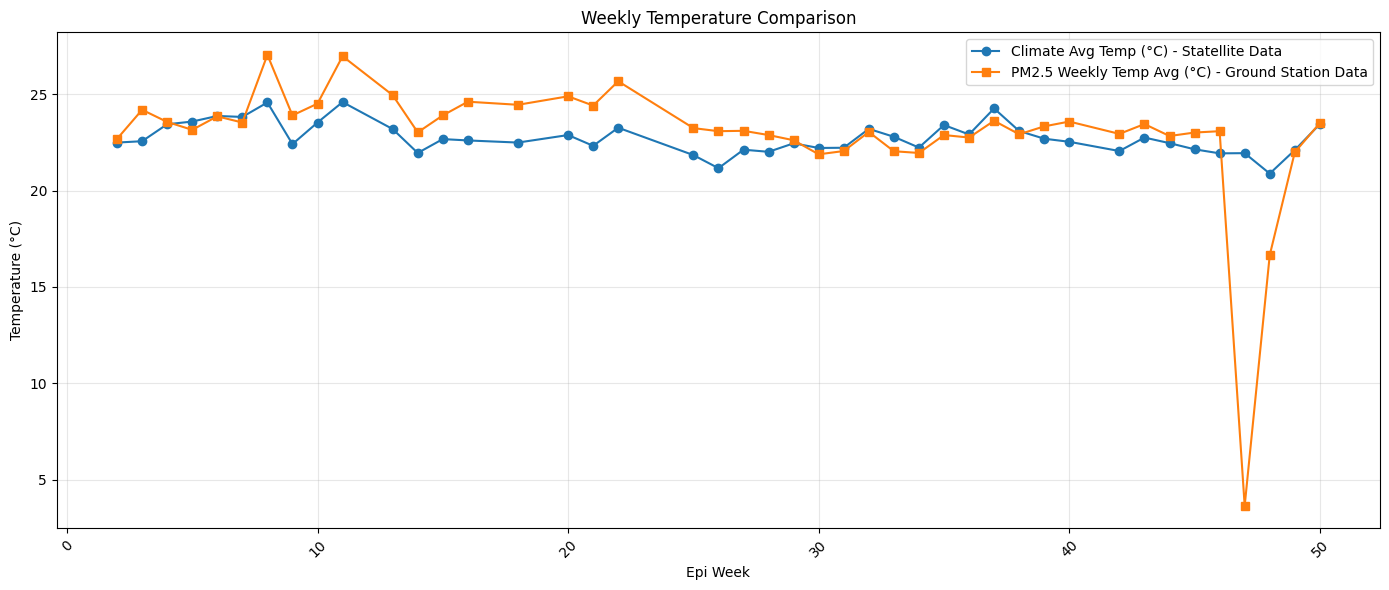

In [7]:
year_sample_df = climate_df[climate_df['epi_year'] == 2024]

plt.figure(figsize=(14, 6))

plt.plot(year_sample_df['epi_week'], year_sample_df['Avg_Temp(C)'], marker='o', label='Climate Avg Temp (°C) - Statellite Data')
plt.plot(year_sample_df['epi_week'], year_sample_df['weekly_temp_avg'], marker='s', label='PM2.5 Weekly Temp Avg (°C) - Ground Station Data')

plt.xlabel('Epi Week')
plt.ylabel('Temperature (°C)')
plt.title('Weekly Temperature Comparison')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()